<a href="https://colab.research.google.com/github/jefersonferreirafagundes-eng/MVP-ML-Analytics/blob/main/C%C3%B3pia_de_MVP_Engenharia_Dados_Desempenho_Alunos_EXECUTADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Engenharia de Dados aplicada ao Desempenho Acadêmico
## Versão executada com o dataset real

**Pergunta central:** quais variáveis disponíveis apresentam maior associação com a nota final dos alunos?

> Esta execução foi realizada em ambiente Python local. As camadas Bronze, Silver e Gold foram materializadas em arquivos CSV para reproduzir a lógica do pipeline. No Databricks, a mesma lógica pode ser persistida como tabelas Delta.

> **Importante:** associação estatística e capacidade preditiva não comprovam causalidade.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path(r"/mnt/data/student_productivity_distraction_dataset_20000.csv")
OUTPUT_DIR = Path(r"/mnt/data/MVP_Engenharia_Dados_Desempenho_Alunos_EXECUTADO")
OUTPUT_DIR.mkdir(exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
print("Dimensões do dataset:", df_raw.shape)
print("Colunas:", df_raw.columns.tolist())
df_raw.head()

Dimensões do dataset: (5999, 18)
Colunas: ['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


## 1. Camada Bronze

A Bronze preserva os dados originais. Nesta execução local, ela é persistida em CSV.

In [ ]:
bronze_path = OUTPUT_DIR / "bronze_student_raw.csv"
df_bronze = df_raw.copy()
df_bronze.to_csv(bronze_path, index=False)
print("Bronze:", bronze_path)
print("Linhas:", len(df_bronze), "| Colunas:", len(df_bronze.columns))

Bronze: /mnt/data/MVP_Engenharia_Dados_Desempenho_Alunos_EXECUTADO/bronze_student_raw.csv
Linhas: 5999 | Colunas: 18


## 2. Qualidade inicial

In [ ]:
quality = pd.DataFrame({
    "tipo": df_bronze.dtypes.astype(str),
    "nulos": df_bronze.isna().sum(),
    "unicos": df_bronze.nunique(dropna=False),
})
print("Duplicidades exatas:", df_bronze.duplicated().sum())
quality

Duplicidades exatas: 0


,tipo,nulos,unicos
student_id,int64,0,5999
age,int64,0,13
gender,object,0,3
study_hours_per_day,float64,0,951
sleep_hours,float64,0,701
phone_usage_hours,float64,0,1144
social_media_hours,float64,0,801
youtube_hours,float64,0,601
gaming_hours,float64,0,601
breaks_per_day,int64,0,14


In [ ]:
df_bronze.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,5999.0,NaN,NaN,NaN,3000.0,1731.906464,1.0,1500.5,3000.0,4499.5,5999.0
age,5999.0,NaN,NaN,NaN,22.987665,3.770489,17.0,20.0,23.0,26.0,29.0
gender,5999,3,Male,2897,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,5999.0,NaN,NaN,NaN,5.192992,2.738754,0.5,2.825,5.18,7.56,10.0
sleep_hours,5999.0,NaN,NaN,NaN,6.548315,2.021401,3.0,4.79,6.56,8.33,10.0
phone_usage_hours,5999.0,NaN,NaN,NaN,6.232802,3.325129,0.5,3.35,6.19,9.105,12.0
social_media_hours,5999.0,NaN,NaN,NaN,3.987838,2.292109,0.0,2.015,3.98,5.95,8.0
youtube_hours,5999.0,NaN,NaN,NaN,3.003029,1.72086,0.0,1.51,3.03,4.48,6.0
gaming_hours,5999.0,NaN,NaN,NaN,2.971165,1.744649,0.0,1.455,2.96,4.45,6.0
breaks_per_day,5999.0,NaN,NaN,NaN,7.527421,3.988004,1.0,4.0,7.0,11.0,14.0


## 3. Camada Silver

Tratamentos:
- remoção de duplicidades exatas;
- padronização de `gender`;
- validação de faixas físicas de horas/dia;
- preservação de todas as variáveis originais.

In [ ]:
df_silver = df_bronze.drop_duplicates().copy()
df_silver["gender"] = df_silver["gender"].astype(str).str.strip().str.title()

hour_cols = [
    "study_hours_per_day", "sleep_hours", "phone_usage_hours",
    "social_media_hours", "youtube_hours", "gaming_hours"
]
for c in hour_cols:
    df_silver.loc[~df_silver[c].between(0, 24), c] = np.nan

df_silver.loc[df_silver["age"] < 0, "age"] = np.nan
df_silver.loc[df_silver["final_grade"] < 0, "final_grade"] = np.nan

silver_path = OUTPUT_DIR / "silver_student_clean.csv"
df_silver.to_csv(silver_path, index=False)

print("Linhas Silver:", len(df_silver))
print("Nulos após validação:", int(df_silver.isna().sum().sum()))

Linhas Silver: 5999
Nulos após validação: 0


## 4. Camada Gold e Feature Engineering

As variáveis derivadas abaixo são proxies. Tempos digitais podem se sobrepor.

In [ ]:
df_gold = df_silver.copy()
df_gold["total_screen_time_proxy"] = (
    df_gold["phone_usage_hours"] +
    df_gold["youtube_hours"] +
    df_gold["gaming_hours"]
)
df_gold["entertainment_hours"] = (
    df_gold["social_media_hours"] +
    df_gold["youtube_hours"] +
    df_gold["gaming_hours"]
)
df_gold["study_sleep_ratio"] = np.where(
    df_gold["sleep_hours"] > 0,
    df_gold["study_hours_per_day"] / df_gold["sleep_hours"],
    np.nan
)
df_gold["digital_entertainment_ratio"] = np.where(
    df_gold["study_hours_per_day"] > 0,
    df_gold["entertainment_hours"] / df_gold["study_hours_per_day"],
    np.nan
)

gold_path = OUTPUT_DIR / "gold_student_analysis.csv"
df_gold.to_csv(gold_path, index=False)
print("Gold:", gold_path)
df_gold.head()

Gold: /mnt/data/MVP_Engenharia_Dados_Desempenho_Alunos_EXECUTADO/gold_student_analysis.csv


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_screen_time_proxy,entertainment_hours,study_sleep_ratio,digital_entertainment_ratio
0,1,23.0,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78,10.47,9.82,1.198347,2.257471
1,2,20.0,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99,10.34,6.37,0.933131,1.037459
2,3,29.0,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60,9.72,8.52,1.527607,1.710843
3,4,27.0,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87,18.33,12.22,0.696507,3.830721
4,5,24.0,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90,14.13,12.70,1.235105,1.655802


## 5. Catálogo de dados

In [ ]:
catalog = pd.DataFrame([
    ["student_id","int","Identificador do registro","identificador","não usar como preditor"],
    ["age","numérico","Idade do estudante",">=0","explicativa"],
    ["gender","categórico","Gênero informado","categorias da fonte","explicativa"],
    ["study_hours_per_day","numérico","Horas de estudo/dia","0–24","explicativa"],
    ["sleep_hours","numérico","Horas de sono/dia","0–24","explicativa"],
    ["phone_usage_hours","numérico","Uso do celular/dia","0–24","explicativa"],
    ["social_media_hours","numérico","Uso de redes sociais/dia","0–24","explicativa"],
    ["youtube_hours","numérico","Uso do YouTube/dia","0–24","explicativa"],
    ["gaming_hours","numérico","Jogos/dia","0–24","explicativa"],
    ["breaks_per_day","numérico","Pausas por dia","conforme fonte","explicativa"],
    ["coffee_intake_mg","numérico","Consumo de cafeína","conforme fonte","explicativa"],
    ["exercise_minutes","numérico","Minutos de exercício","conforme fonte","explicativa"],
    ["assignments_completed","numérico","Atividades concluídas","conforme fonte","explicativa"],
    ["attendance_percentage","numérico","Percentual de frequência","0–100","explicativa"],
    ["stress_level","numérico","Nível de estresse","conforme fonte","explicativa"],
    ["focus_score","numérico","Índice de foco","conforme fonte","explicativa"],
    ["final_grade","numérico","Nota final","observado 40–99,99","alvo"],
    ["productivity_score","numérico","Índice de produtividade","derivado","avaliar antes de modelar"],
], columns=["atributo","tipo","descricao","dominio","papel"])
catalog.to_csv(OUTPUT_DIR / "catalogo_dados_executado.csv", index=False)
catalog

,atributo,tipo,descricao,dominio,papel
0,student_id,int,Identificador do registro,identificador,não usar como preditor
1,age,numérico,Idade do estudante,>=0,explicativa
2,gender,categórico,Gênero informado,categorias da fonte,explicativa
3,study_hours_per_day,numérico,Horas de estudo/dia,0–24,explicativa
4,sleep_hours,numérico,Horas de sono/dia,0–24,explicativa
5,phone_usage_hours,numérico,Uso do celular/dia,0–24,explicativa
6,social_media_hours,numérico,Uso de redes sociais/dia,0–24,explicativa
7,youtube_hours,numérico,Uso do YouTube/dia,0–24,explicativa
8,gaming_hours,numérico,Jogos/dia,0–24,explicativa
9,breaks_per_day,numérico,Pausas por dia,conforme fonte,explicativa


## 6. Distribuição da nota final

count    5999.000000
mean       70.212404
std        17.173194
min        40.000000
25%        55.450000
50%        70.100000
75%        85.030000
max        99.990000
Name: final_grade, dtype: float64


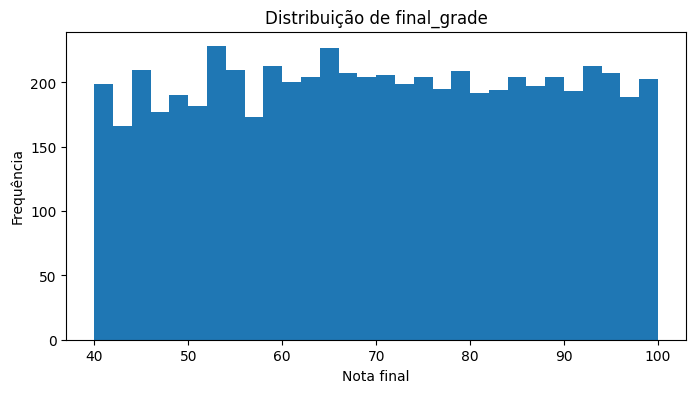

In [ ]:
print(df_gold["final_grade"].describe())

plt.figure(figsize=(8,4))
plt.hist(df_gold["final_grade"], bins=30)
plt.xlabel("Nota final")
plt.ylabel("Frequência")
plt.title("Distribuição de final_grade")
plt.show()

## 7. Correlação com a nota final

In [ ]:
numeric_cols = [
    c for c in df_gold.select_dtypes(include=np.number).columns
    if c not in ["student_id", "final_grade"]
]
corr = pd.DataFrame({
    "pearson": df_gold[numeric_cols + ["final_grade"]].corr(method="pearson")["final_grade"].drop("final_grade"),
    "spearman": df_gold[numeric_cols + ["final_grade"]].corr(method="spearman")["final_grade"].drop("final_grade"),
})
corr["abs_pearson"] = corr["pearson"].abs()
corr = corr.sort_values("abs_pearson", ascending=False)
corr.to_csv(OUTPUT_DIR / "correlacoes_final_grade.csv")
corr

,pearson,spearman,abs_pearson
youtube_hours,-0.037898,-0.037782,0.037898
gaming_hours,0.033186,0.032914,0.033186
study_sleep_ratio,-0.032497,-0.032546,0.032497
stress_level,-0.028850,-0.028741,0.028850
study_hours_per_day,-0.026336,-0.026195,0.026336
sleep_hours,0.021743,0.021729,0.021743
attendance_percentage,-0.018781,-0.018425,0.018781
assignments_completed,0.015354,0.015263,0.015354
productivity_score,-0.012625,-0.010176,0.012625
focus_score,-0.009799,-0.009747,0.009799


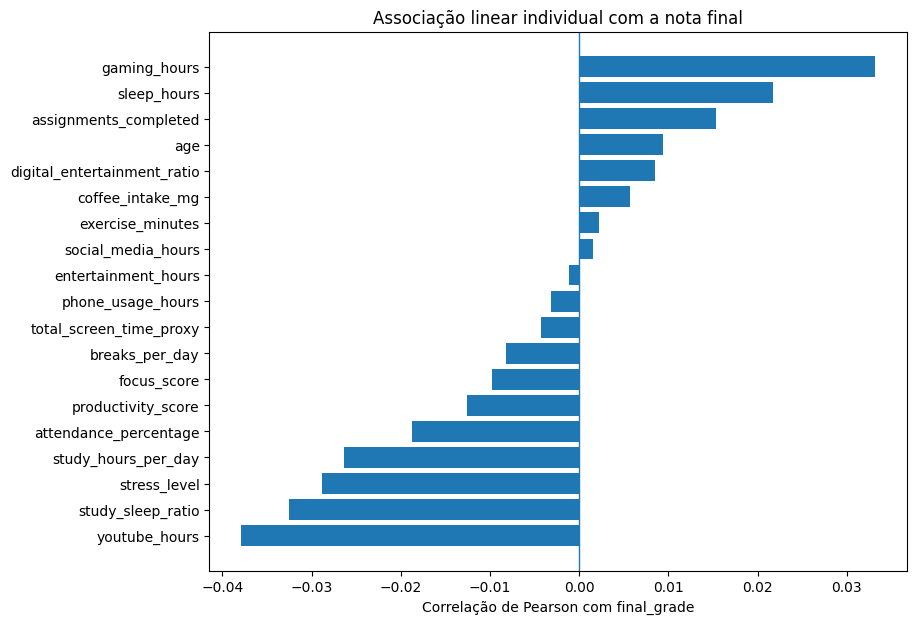

In [ ]:
plot_corr = corr.sort_values("pearson")
plt.figure(figsize=(9,7))
plt.barh(plot_corr.index, plot_corr["pearson"])
plt.axvline(0, linewidth=1)
plt.xlabel("Correlação de Pearson com final_grade")
plt.title("Associação linear individual com a nota final")
plt.show()

## 8. Verificação de `productivity_score`

Antes da regressão multivariada, verificamos se `productivity_score` é independente das demais variáveis ou se é uma variável derivada.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

components = [
    "study_hours_per_day", "sleep_hours", "phone_usage_hours",
    "attendance_percentage", "stress_level", "focus_score"
]
aux = LinearRegression().fit(df_gold[components], df_gold["productivity_score"])
reconstructed = aux.predict(df_gold[components])
r2_productivity = r2_score(df_gold["productivity_score"], reconstructed)

print("R² de reconstrução de productivity_score:", r2_productivity)
pd.DataFrame({
    "variavel": components,
    "coeficiente": aux.coef_
})

R² de reconstrução de productivity_score: 0.9999999685517913


,variavel,coeficiente
0,study_hours_per_day,4.316376
1,sleep_hours,2.697748
2,phone_usage_hours,-1.618629
3,attendance_percentage,0.161866
4,stress_level,-1.079116
5,focus_score,0.323728


### Decisão de modelagem

Como `productivity_score` é praticamente reconstruído pelas variáveis componentes, ele será excluído da análise explicativa principal para evitar multicolinearidade severa e dupla contagem da mesma informação.

## 9. Regressão múltipla sem `productivity_score`

In [ ]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

base_features = [
    c for c in df_gold.columns
    if c not in [
        "student_id", "final_grade", "productivity_score",
        "total_screen_time_proxy", "entertainment_hours",
        "study_sleep_ratio", "digital_entertainment_ratio"
    ]
]

num_features = [c for c in base_features if df_gold[c].dtype != "object"]
cat_features = [c for c in base_features if df_gold[c].dtype == "object"]

X_num = pd.DataFrame(
    StandardScaler().fit_transform(df_gold[num_features]),
    columns=num_features, index=df_gold.index
)
X_cat = pd.get_dummies(df_gold[cat_features], drop_first=True, dtype=float)
X_ols = pd.concat([X_num, X_cat], axis=1)
X_ols = sm.add_constant(X_ols).astype(float)
y = df_gold["final_grade"].astype(float)

ols = sm.OLS(y, X_ols).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:            final_grade   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.081
Date:                Sat, 22 Aug 2026   Prob (F-statistic):            0.00685
Time:                        20:33:06   Log-Likelihood:                -25552.
No. Observations:                5999   AIC:                         5.114e+04
Df Residuals:                    5982   BIC:                         5.125e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    70.21

In [ ]:
ols_table = pd.DataFrame({
    "coeficiente": ols.params,
    "p_valor": ols.pvalues,
    "ic_min": ols.conf_int()[0],
    "ic_max": ols.conf_int()[1],
})
ols_table["abs_coef"] = ols_table["coeficiente"].abs()
ols_table = ols_table.sort_values("abs_coef", ascending=False)
ols_table.to_csv(OUTPUT_DIR / "regressao_ols.csv")
ols_table

,coeficiente,p_valor,ic_min,ic_max,abs_coef
const,70.216562,0.000000,69.588578,70.844546,70.216562
youtube_hours,-0.661509,0.002844,-1.095894,-0.227125,0.661509
gender_Other,-0.598318,0.608192,-2.886121,1.689485,0.598318
gaming_hours,0.589820,0.007799,0.155390,1.024249,0.589820
stress_level,-0.477827,0.031113,-0.912270,-0.043385,0.477827
study_hours_per_day,-0.462425,0.037035,-0.897030,-0.027820,0.462425
sleep_hours,0.368957,0.095867,-0.065323,0.803237,0.368957
attendance_percentage,-0.314001,0.156652,-0.748532,0.120529,0.314001
assignments_completed,0.291615,0.188385,-0.142942,0.726171,0.291615
breaks_per_day,-0.176377,0.426536,-0.611195,0.258442,0.176377


## 10. Machine Learning — comparação com baseline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

features_ml = base_features
X = df_gold[features_ml].copy()
y = df_gold["final_grade"].copy()

num = [c for c in features_ml if X[c].dtype != "object"]
cat = [c for c in features_ml if X[c].dtype == "object"]

prep = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

models = {
    "DummyMean": DummyRegressor(strategy="mean"),
    "LinearRegression": Pipeline([("prep", prep), ("model", LinearRegression())]),
    "Ridge": Pipeline([("prep", prep), ("model", Ridge(alpha=1.0))]),
    "RandomForest": Pipeline([("prep", prep), ("model", RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ))]),
    "GradientBoosting": Pipeline([("prep", prep), ("model", GradientBoostingRegressor(random_state=42))]),
}

rows = []
fitted = {}
for name, model in models.items():
    start = time.perf_counter()
    if name == "DummyMean":
        model.fit(np.zeros((len(y_train),1)), y_train)
        pred = model.predict(np.zeros((len(y_test),1)))
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    rows.append({
        "modelo": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
        "tempo_s": time.perf_counter() - start
    })
    fitted[name] = model

results_df = pd.DataFrame(rows).sort_values("RMSE")
results_df.to_csv(OUTPUT_DIR / "metricas_modelos.csv", index=False)
results_df

,modelo,MAE,RMSE,R2,tempo_s
0,DummyMean,14.292170,16.623880,-0.000018,0.001099
2,Ridge,14.298040,16.640474,-0.002015,0.014330
1,LinearRegression,14.298046,16.640490,-0.002017,0.026178
3,RandomForest,14.375399,16.788756,-0.019952,3.914516
4,GradientBoosting,14.383387,16.829136,-0.024865,1.171488


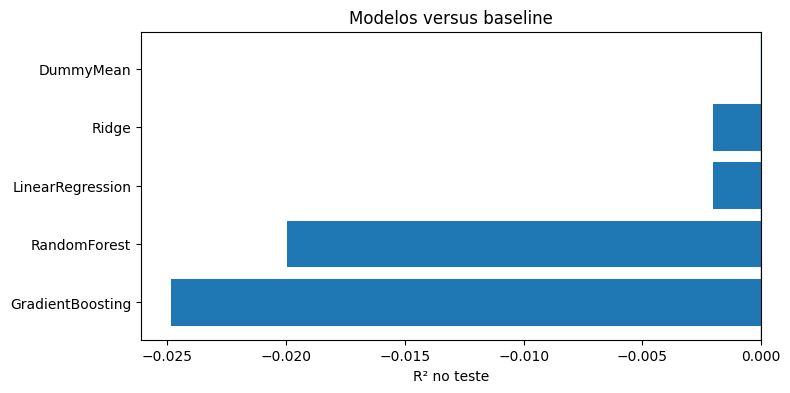

In [ ]:
plt.figure(figsize=(8,4))
plot_results = results_df.sort_values("R2")
plt.barh(plot_results["modelo"], plot_results["R2"])
plt.axvline(0, linewidth=1)
plt.xlabel("R² no teste")
plt.title("Modelos versus baseline")
plt.show()

## 11. Permutation Importance — Ridge

Como nenhum modelo demonstra boa capacidade preditiva, a importância deve ser lida com cautela. Valores próximos de zero indicam pouca contribuição incremental.

In [ ]:
from sklearn.inspection import permutation_importance

ridge = fitted["Ridge"]
perm = permutation_importance(
    ridge, X_test, y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)
perm_df = pd.DataFrame({
    "variavel": X_test.columns,
    "importancia_media": perm.importances_mean,
    "desvio": perm.importances_std
}).sort_values("importancia_media", ascending=False)
perm_df.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)
perm_df

## 12. Resposta objetiva ao problema

A execução deve ser interpretada com base em três evidências:

1. magnitude das correlações com `final_grade`;
2. regressão múltipla;
3. capacidade dos modelos de superar o `DummyRegressor`.

Se as correlações forem muito pequenas e os modelos apresentarem R² próximo de zero ou negativo, a conclusão é que **as variáveis disponíveis não explicam adequadamente a variação da nota final neste dataset**.

In [ ]:
top = corr.iloc[0]
best = results_df.iloc[0]
dummy = results_df[results_df["modelo"]=="DummyMean"].iloc[0]

print(f"Maior correlação absoluta: {corr.index[0]} = {top['pearson']:.4f}")
print(f"Melhor RMSE observado: {best['modelo']} = {best['RMSE']:.4f}")
print(f"RMSE DummyMean: {dummy['RMSE']:.4f}")
print(f"R² do melhor modelo por RMSE: {best['R2']:.4f}")

if corr["abs_pearson"].max() < 0.10 and results_df[results_df["modelo"]!="DummyMean"]["R2"].max() <= 0.05:
    print("\nCONCLUSÃO:")
    print("As associações individuais são muito fracas e os modelos não demonstram capacidade preditiva relevante sobre a nota final.")
    print("O dataset não oferece evidência suficiente para afirmar que as variáveis analisadas expliquem diferenças de final_grade.")

Maior correlação absoluta: youtube_hours = -0.0379
Melhor RMSE observado: DummyMean = 16.6239
RMSE DummyMean: 16.6239
R² do melhor modelo por RMSE: -0.0000

CONCLUSÃO:
As associações individuais são muito fracas e os modelos não demonstram capacidade preditiva relevante sobre a nota final.
O dataset não oferece evidência suficiente para afirmar que as variáveis analisadas expliquem diferenças de final_grade.


## 13. FAZER CONCLUSÃO

- O dataset contém 5.999 registros, apesar do nome do arquivo sugerir 20.000.
- `productivity_score` é praticamente uma combinação de outras variáveis e deve ser tratado como variável derivada.
- O conjunto de dados não demonstra relações fortes com `final_grade`.
